# Notebook 01 — Analyse Exploratoire des Données

Premier contact avec le dataset : on cherche à comprendre qui sont les clients, quels comportements précèdent le départ, et combien coûte réellement le churn pour l'entreprise.

Ce notebook pose toutes les hypothèses qui guideront les choix de modélisation — features à créer, encodages, traitement des valeurs manquantes, métriques prioritaires.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Charger le dataset
df = pd.read_csv('../data/customer_churn_business_dataset.csv')
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print(f'Shape: {df.shape}')
df.head()

Shape: (10000, 32)


,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


## 1. Structure et qualité des données

In [2]:
# Types, valeurs manquantes, cardinalités
info = pd.DataFrame({
    'dtype':   df.dtypes,
    'non_null': df.notna().sum(),
    'pct_missing': (df.isna().mean() * 100).round(2),
    'n_unique': df.nunique(),
})
print(info.to_string())

                          dtype  non_null  pct_missing  n_unique
customer_id                 str     10000         0.00     10000
gender                      str     10000         0.00         2
age                       int64     10000         0.00        57
country                     str     10000         0.00         7
city                        str     10000         0.00         7
customer_segment            str     10000         0.00         3
tenure_months             int64     10000         0.00        59
signup_channel              str     10000         0.00         3
contract_type               str     10000         0.00         3
monthly_logins            int64     10000         0.00        53
weekly_active_days        int64     10000         0.00         8
avg_session_time        float64     10000         0.00      9777
features_used             int64     10000         0.00        15
usage_growth_rate       float64     10000         0.00       104
last_login_days_ago      

In [3]:
# Statistiques descriptives
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,10000,10000,CUST_00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,10000,2,Male,5013,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,10000.0,NaN,NaN,NaN,45.9061,16.420416,18.0,32.0,46.0,60.0,74.0
country,10000,7,Bangladesh,1494,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,10000,7,London,1518,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_segment,10000,3,Individual,5984,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure_months,10000.0,NaN,NaN,NaN,30.1557,17.099517,1.0,16.0,30.0,45.0,59.0
signup_channel,10000,3,Web,5036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contract_type,10000,3,Monthly,4967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_logins,10000.0,NaN,NaN,NaN,19.672,9.838003,0.0,13.0,20.0,26.0,54.0


## 2. Problématique business — Chiffrage initial

In [4]:
n_total   = len(df)
n_churn   = df['churn'].sum()
rate      = n_churn / n_total
rev_total = df['total_revenue'].sum()
rev_risk  = df.loc[df['churn']==1, 'total_revenue'].sum()

print(f'Clients totaux       : {n_total:,}')
print(f'Churners             : {n_churn:,}  ({rate:.1%} du portefeuille)')
print(f'Revenu total         : {rev_total:,.0f} €')
print(f'Revenu churners      : {rev_risk:,.0f} €  ({rev_risk/rev_total:.1%} du CA total)')
print()
print('→ Problématique : réduire le taux de churn de 5 points absolus permettrait de')
print(f'  sauvegarder ~{rev_total * 0.05 / rate:,.0f} € de revenu annuel.')
print('  KPI de succès : F1-score ≥ 0.75 sur la classe churn=1 (minimiser les faux négatifs).')

Clients totaux       : 10,000
Churners             : 1,021  (10.2% du portefeuille)
Revenu total         : 10,570,180 €
Revenu churners      : 862,640 €  (8.2% du CA total)

→ Problématique : réduire le taux de churn de 5 points absolus permettrait de
  sauvegarder ~5,176,386 € de revenu annuel.
  KPI de succès : F1-score ≥ 0.75 sur la classe churn=1 (minimiser les faux négatifs).


## 3. Distribution de la variable cible

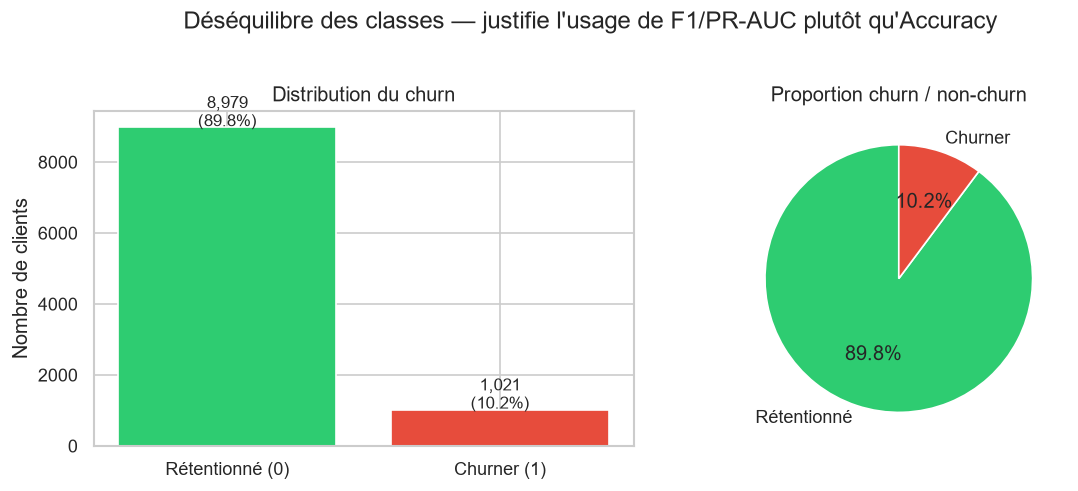

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df['churn'].value_counts()
axes[0].bar(['Rétentionné (0)', 'Churner (1)'], counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribution du churn')
axes[0].set_ylabel('Nombre de clients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f'{v:,}\n({v/n_total:.1%})', ha='center', fontsize=10)

axes[1].pie(counts.values, labels=['Rétentionné', 'Churner'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proportion churn / non-churn')

plt.suptitle('Déséquilibre des classes — justifie l\'usage de F1/PR-AUC plutôt qu\'Accuracy', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/01_class_distribution.png', bbox_inches='tight')
plt.show()

## 4. Corrélation numérique (Pearson / Spearman)

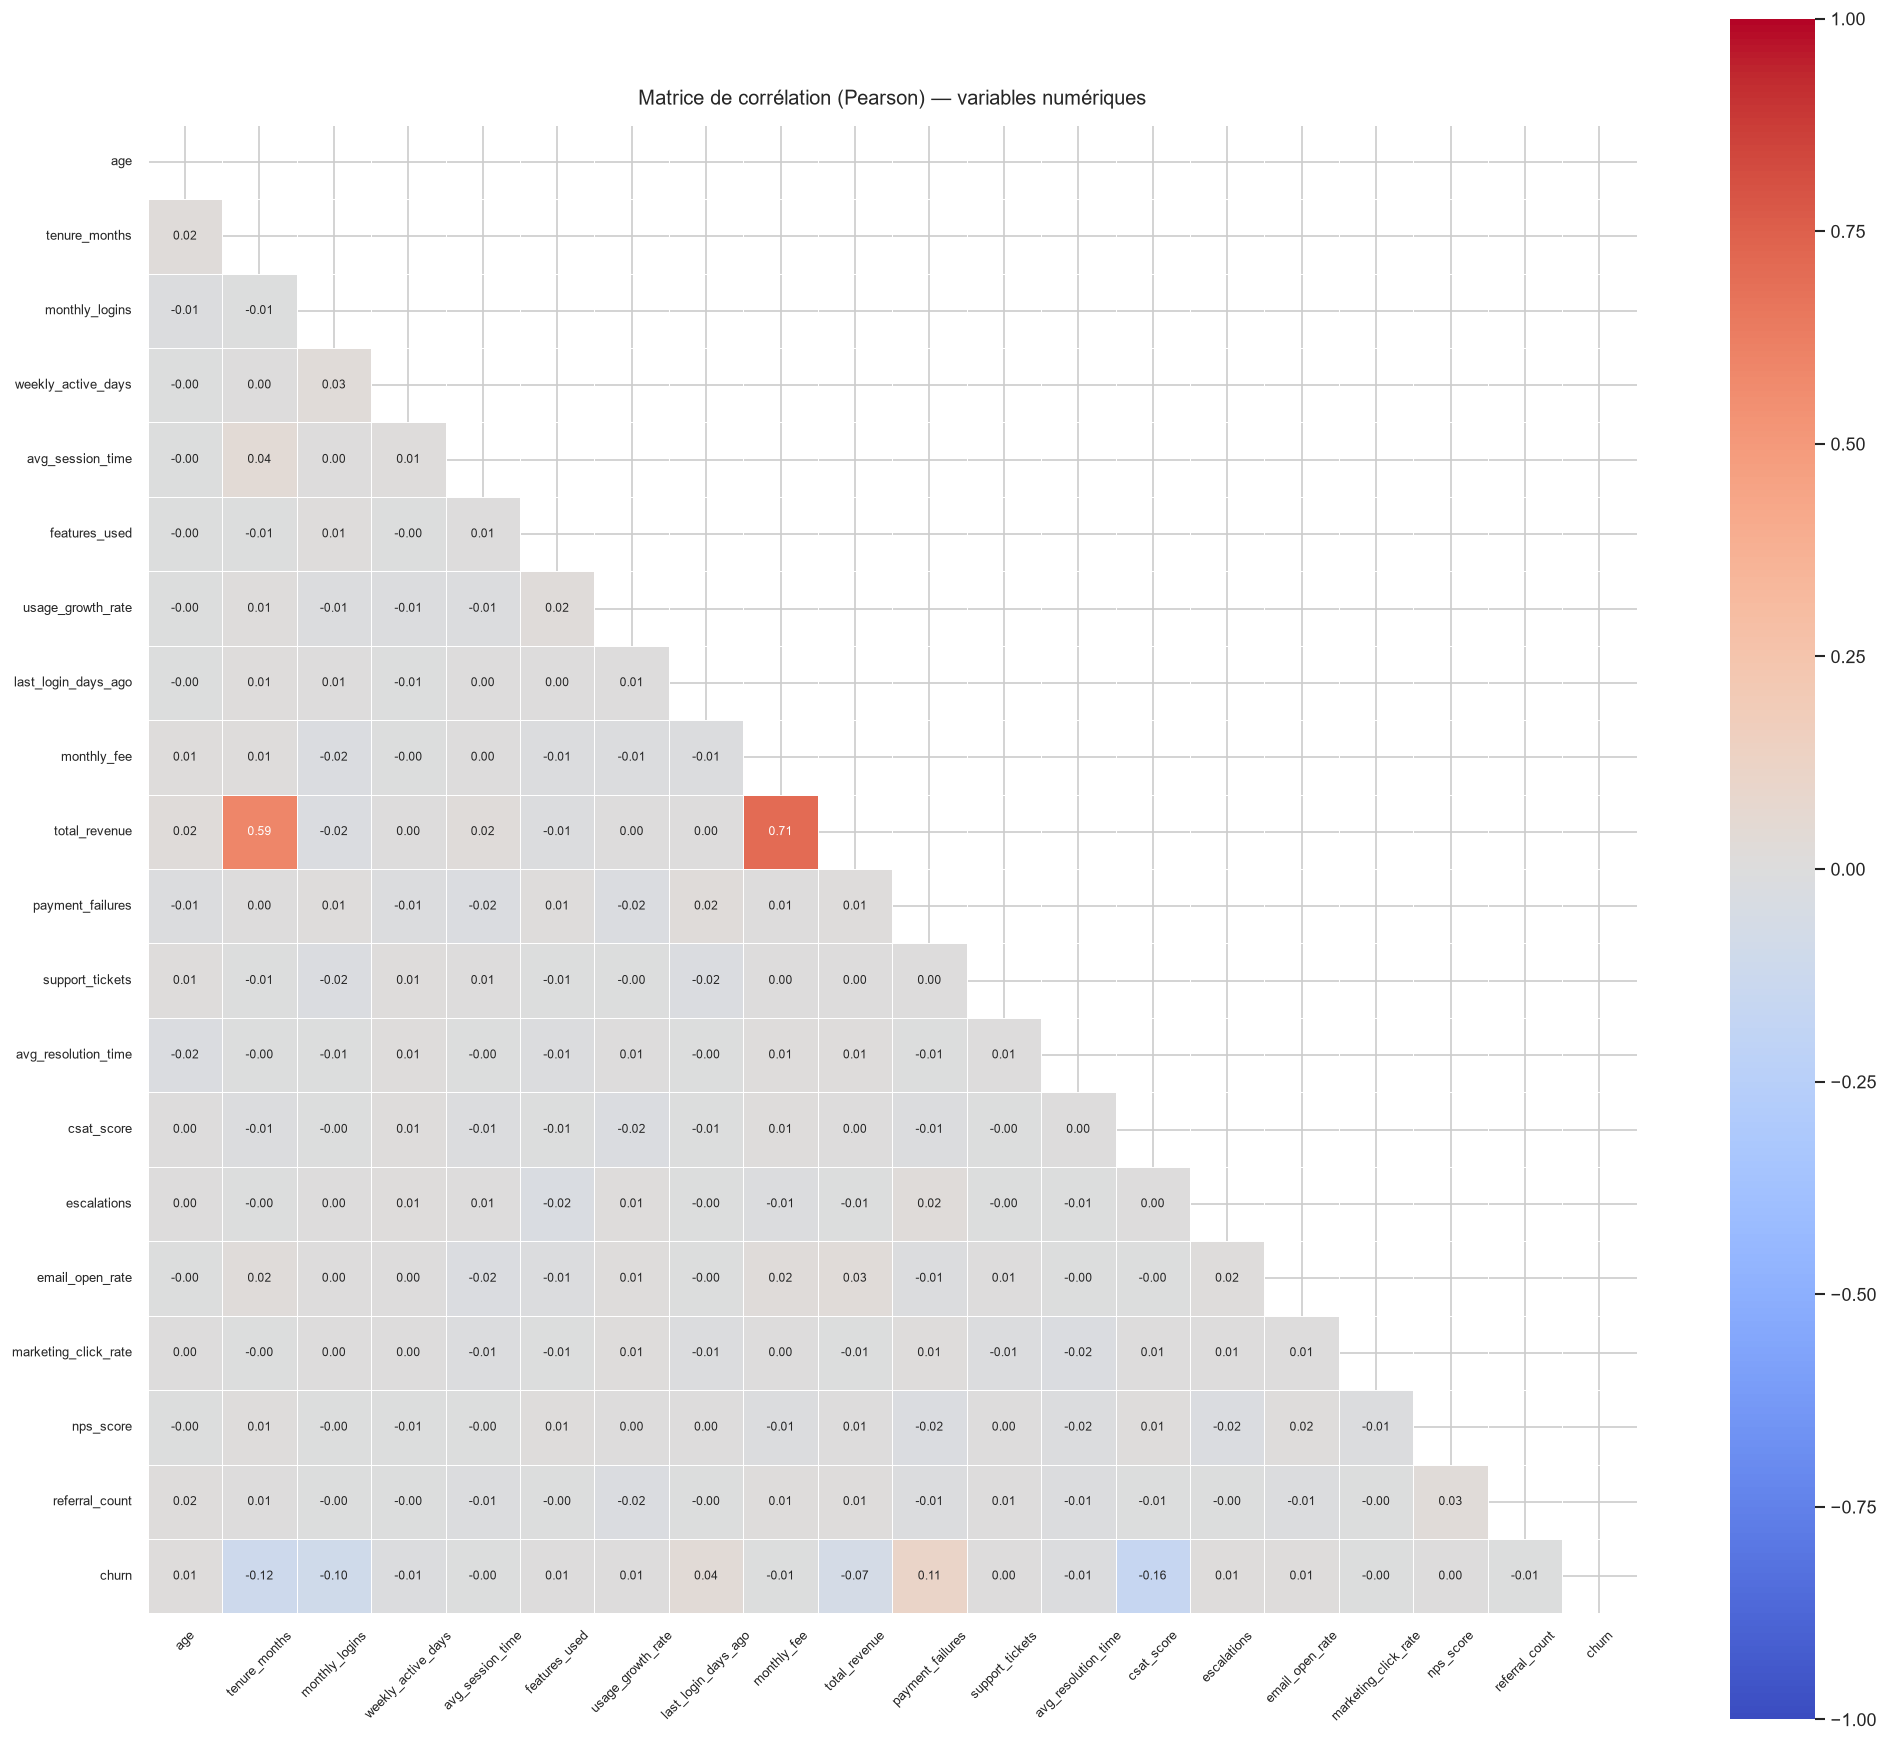

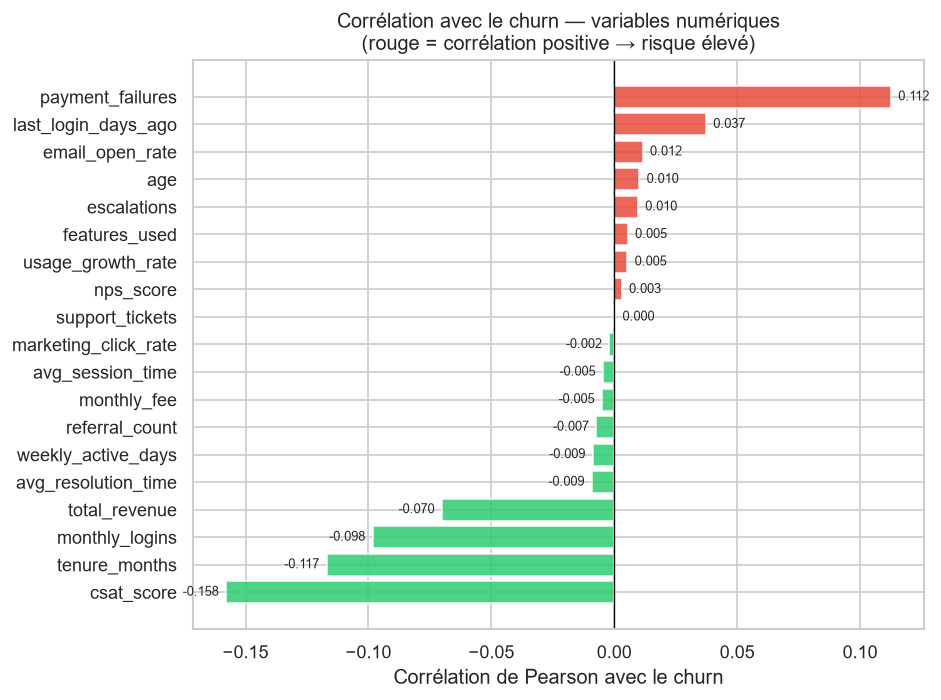

Variables les plus corrélées positivement avec le churn :
escalations            0.009561
age                    0.010155
email_open_rate        0.011506
last_login_days_ago    0.037250
payment_failures       0.112494

Variables les plus corrélées négativement avec le churn :
csat_score            -0.157924
tenure_months         -0.117014
monthly_logins        -0.098339
total_revenue         -0.070120
avg_resolution_time   -0.009172


In [6]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[numeric_cols].corr()

# --- Graphique 1 : heatmap complète (triangle inférieur) ---
# figsize proportionnel au nombre de variables pour que chaque cellule reste lisible
n_vars = len(numeric_cols)
fig, ax = plt.subplots(figsize=(n_vars * 0.85, n_vars * 0.75))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 7},   # police réduite pour 20 variables
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    ax=ax, square=True,
    linewidths=0.3, linecolor='white',
)
ax.set_title('Matrice de corrélation (Pearson) — variables numériques', fontsize=12, pad=12)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig('../reports/figures/01_correlation_numeric.png', bbox_inches='tight')
plt.show()

# --- Graphique 2 : corrélation de chaque variable avec le churn (barplot horizontal) ---
# Plus lisible pour identifier les variables prédictives clés
churn_corr = corr['churn'].drop('churn').sort_values()
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in churn_corr]

fig2, ax2 = plt.subplots(figsize=(8, 6))
bars = ax2.barh(churn_corr.index, churn_corr.values, color=colors, alpha=0.85)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Corrélation de Pearson avec le churn')
ax2.set_title('Corrélation avec le churn — variables numériques\n(rouge = corrélation positive → risque élevé)')
# Annoter chaque barre avec la valeur
for bar, val in zip(bars, churn_corr.values):
    ax2.text(val + (0.003 if val >= 0 else -0.003), bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)
plt.tight_layout()
plt.savefig('../reports/figures/01_correlation_with_churn.png', bbox_inches='tight')
plt.show()

print('Variables les plus corrélées positivement avec le churn :')
print(churn_corr.tail(5).to_string())
print('\nVariables les plus corrélées négativement avec le churn :')
print(churn_corr.head(5).to_string())

## 5. Corrélation catégorielle — Cramér's V

La corrélation de Pearson ne s'applique qu'aux variables numériques. Pour les variables catégorielles (type de contrat, canal d'acquisition, segment client…), il faut une autre mesure : **Cramér's V**, basée sur le test du chi².

Elle varie entre 0 (aucune association) et 1 (association parfaite), et permet de voir si, par exemple, un type de contrat est systématiquement associé au churn.

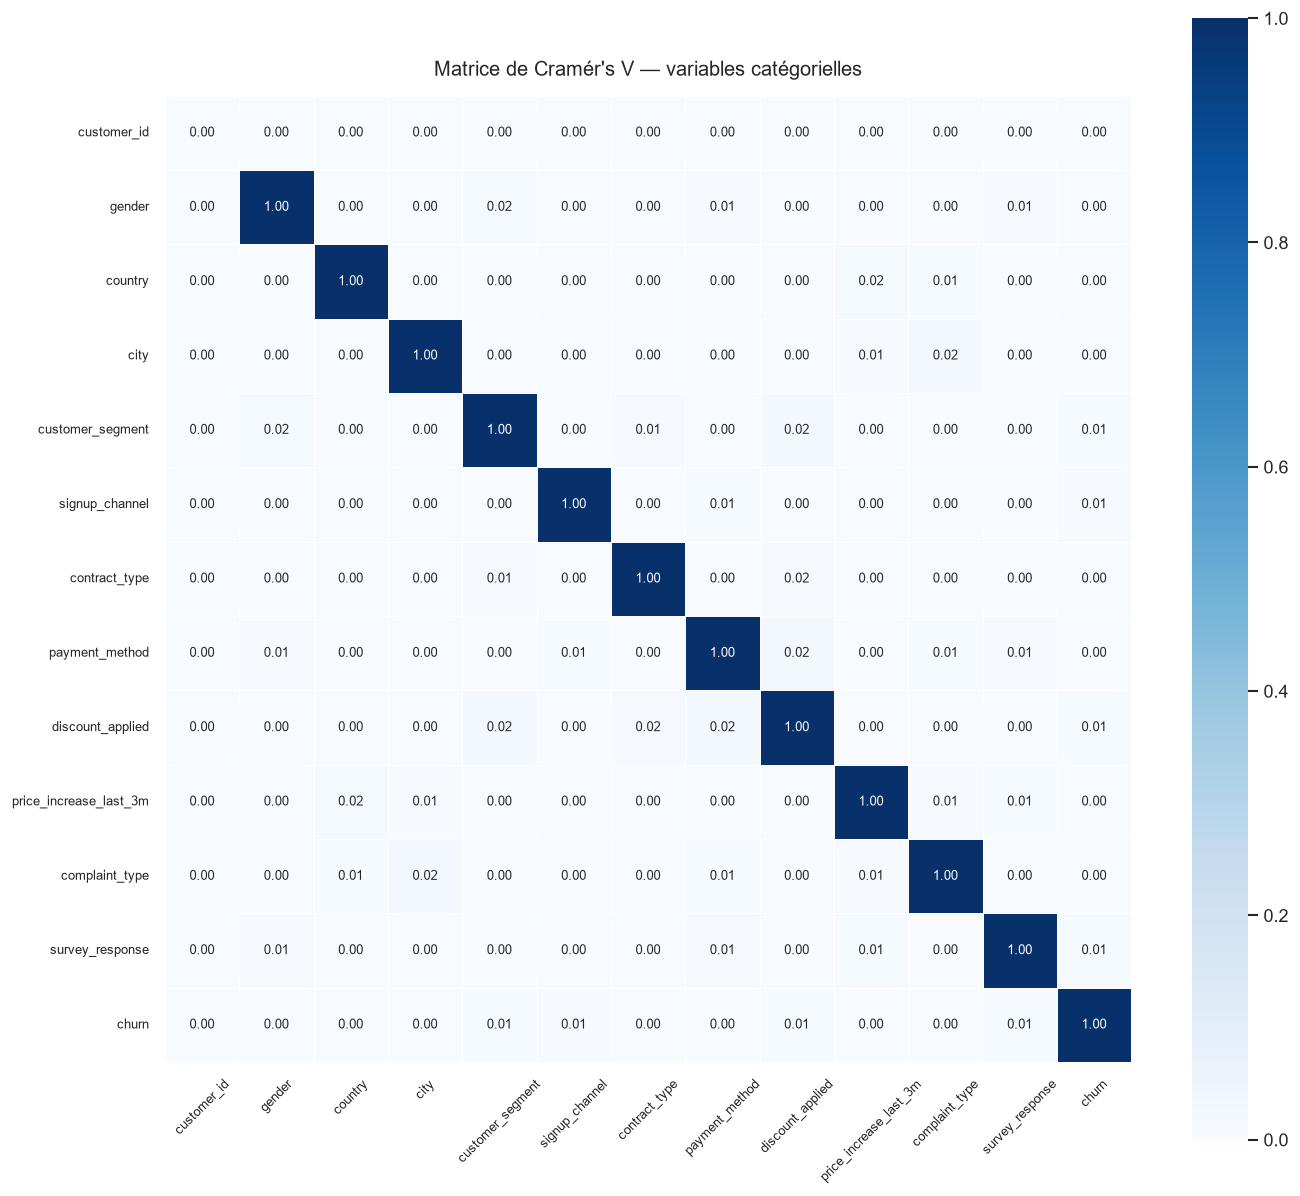

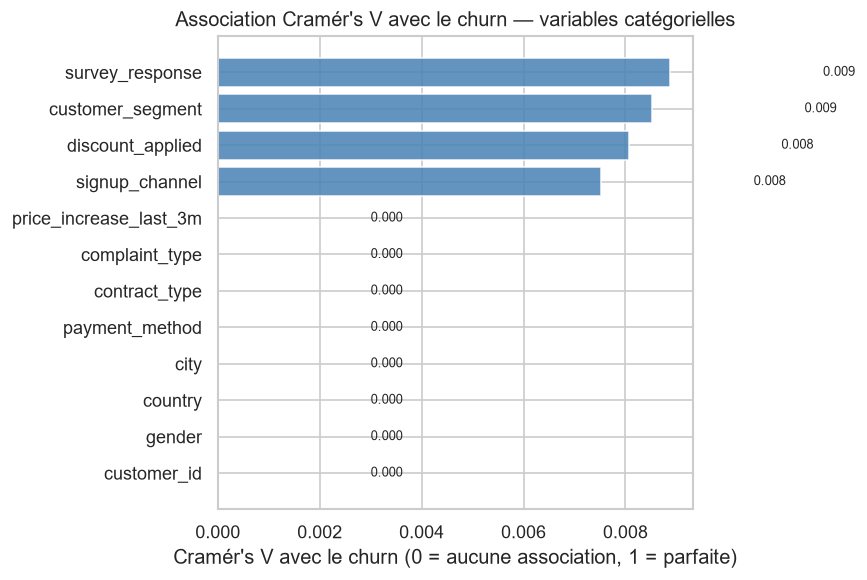


Association avec le churn (Cramér's V) :
survey_response           0.008877
customer_segment          0.008515
discount_applied          0.008060
signup_channel            0.007517
city                      0.000000
country                   0.000000
gender                    0.000000
customer_id               0.000000
price_increase_last_3m    0.000000
complaint_type            0.000000
contract_type             0.000000
payment_method            0.000000


In [7]:
def cramers_v(x: pd.Series, y: pd.Series) -> float:
    """Compute Cramér's V statistic for two categorical variables."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n    = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    # Correction de biais de Bergsma & Wicher
    phi2corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    rcorr    = r - ((r-1)**2) / (n-1)
    kcorr    = k - ((k-1)**2) / (n-1)
    denom    = min(kcorr-1, rcorr-1)
    if denom <= 0:
        return 0.0
    return np.sqrt(phi2corr / denom)


# Inclure 'churn' comme catégorielle pour voir l'association avec toutes les autres
cat_cols = df.select_dtypes(include='object').columns.tolist() + ['churn']

cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for col1 in cat_cols:
    for col2 in cat_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1].astype(str), df[col2].astype(str))

# --- Graphique 1 : heatmap Cramér's V complète ---
# Taille ajustée au nombre de variables catégorielles (12 ici)
n_cat = len(cat_cols)
fig, ax = plt.subplots(figsize=(n_cat * 0.9, n_cat * 0.8))
sns.heatmap(
    cramers_matrix.astype(float),
    annot=True, fmt='.2f', annot_kws={'size': 8},
    cmap='Blues', vmin=0, vmax=1,
    ax=ax, square=True,
    linewidths=0.3, linecolor='white',
)
ax.set_title("Matrice de Cramér's V — variables catégorielles", fontsize=12, pad=12)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig('../reports/figures/01_cramers_v.png', bbox_inches='tight')
plt.show()

# --- Graphique 2 : association de chaque variable catégorielle avec le churn (barplot) ---
# Plus direct que la matrice complète pour prioriser les variables à encoder avec soin
churn_assoc = cramers_matrix['churn'].drop('churn').sort_values(ascending=True)

fig2, ax2 = plt.subplots(figsize=(8, 5))
bars = ax2.barh(churn_assoc.index, churn_assoc.values, color='steelblue', alpha=0.85)
ax2.set_xlabel("Cramér's V avec le churn (0 = aucune association, 1 = parfaite)")
ax2.set_title("Association Cramér's V avec le churn — variables catégorielles")
for bar, val in zip(bars, churn_assoc.values):
    ax2.text(val + 0.003, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../reports/figures/01_cramers_v_churn.png', bbox_inches='tight')
plt.show()

print("\nAssociation avec le churn (Cramér's V) :")
print(churn_assoc.sort_values(ascending=False).to_string())

## 6. Analyse bivariée — variables clés vs. churn

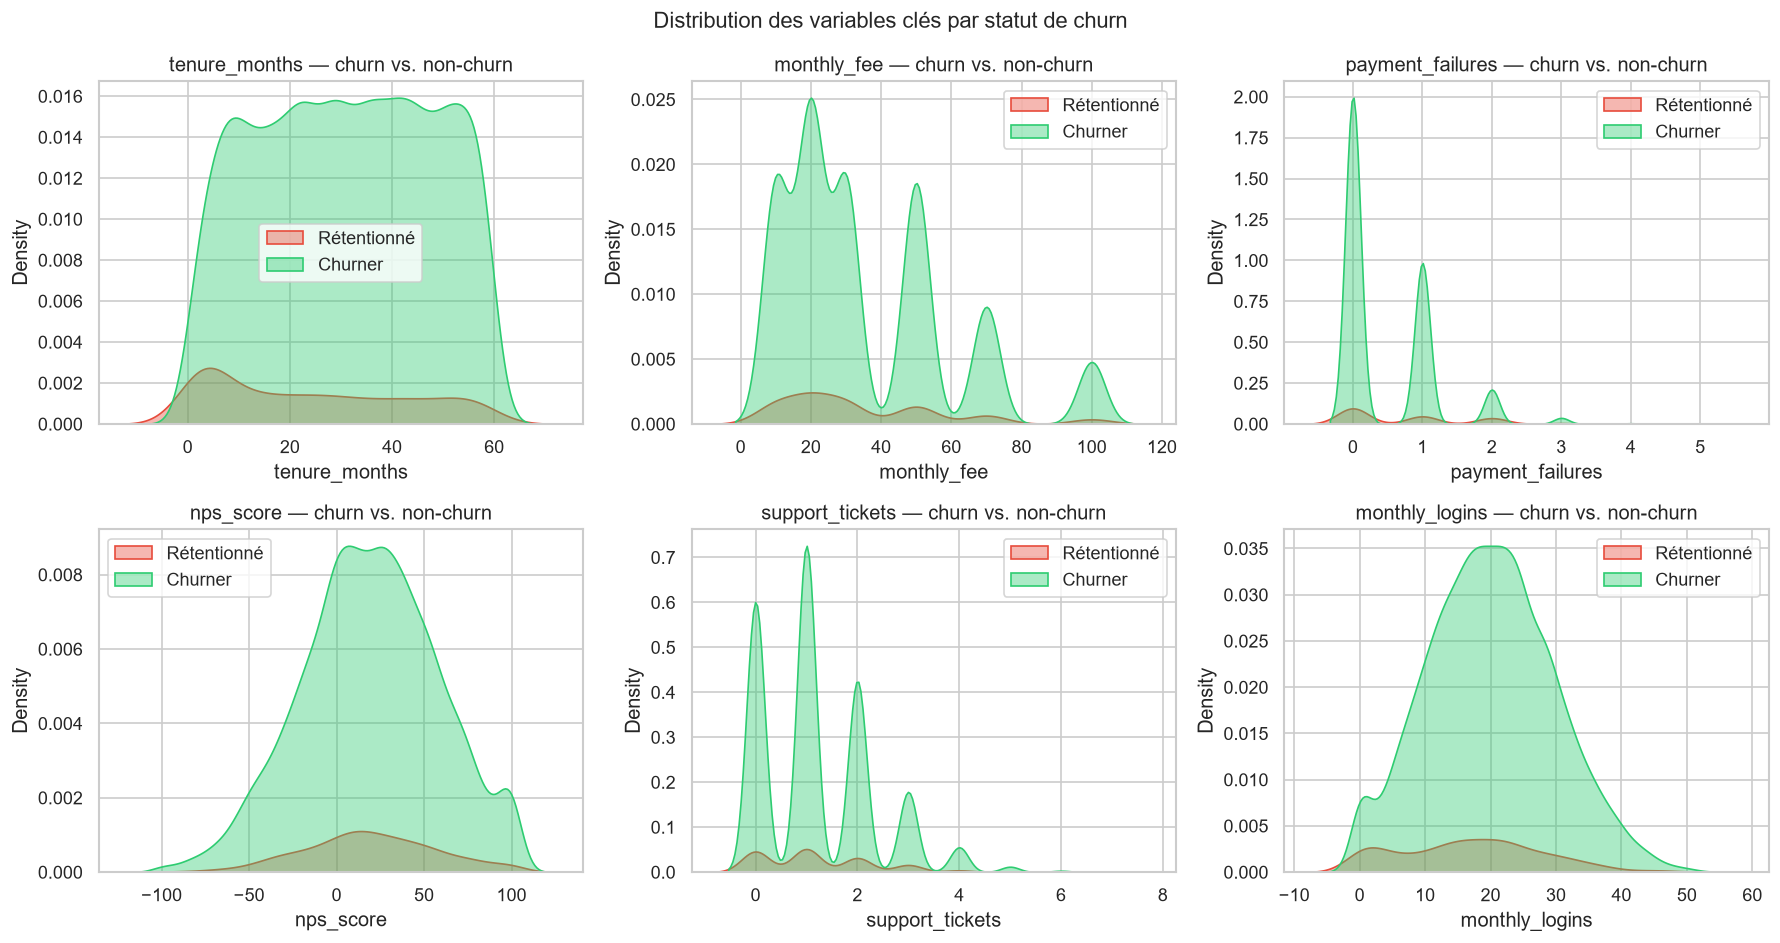

In [8]:
key_vars = ['tenure_months', 'monthly_fee', 'payment_failures', 'nps_score', 'support_tickets', 'monthly_logins']
available = [v for v in key_vars if v in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, var in enumerate(available):
    sns.kdeplot(data=df, x=var, hue='churn', ax=axes[i], fill=True, alpha=0.4,
                palette={0: '#2ecc71', 1: '#e74c3c'})
    axes[i].set_title(f'{var} — churn vs. non-churn')
    axes[i].legend(['Rétentionné', 'Churner'])

plt.suptitle('Distribution des variables clés par statut de churn', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/01_bivariate.png', bbox_inches='tight')
plt.show()

## 7. Taux de churn réel par variable catégorielle

Le Cramér's V (section 5) mesure l'association statistique globale. Cette section calcule le **taux de churn concret** par modalité — ce que l'équipe métier a besoin de voir pour prioriser les actions de rétention.

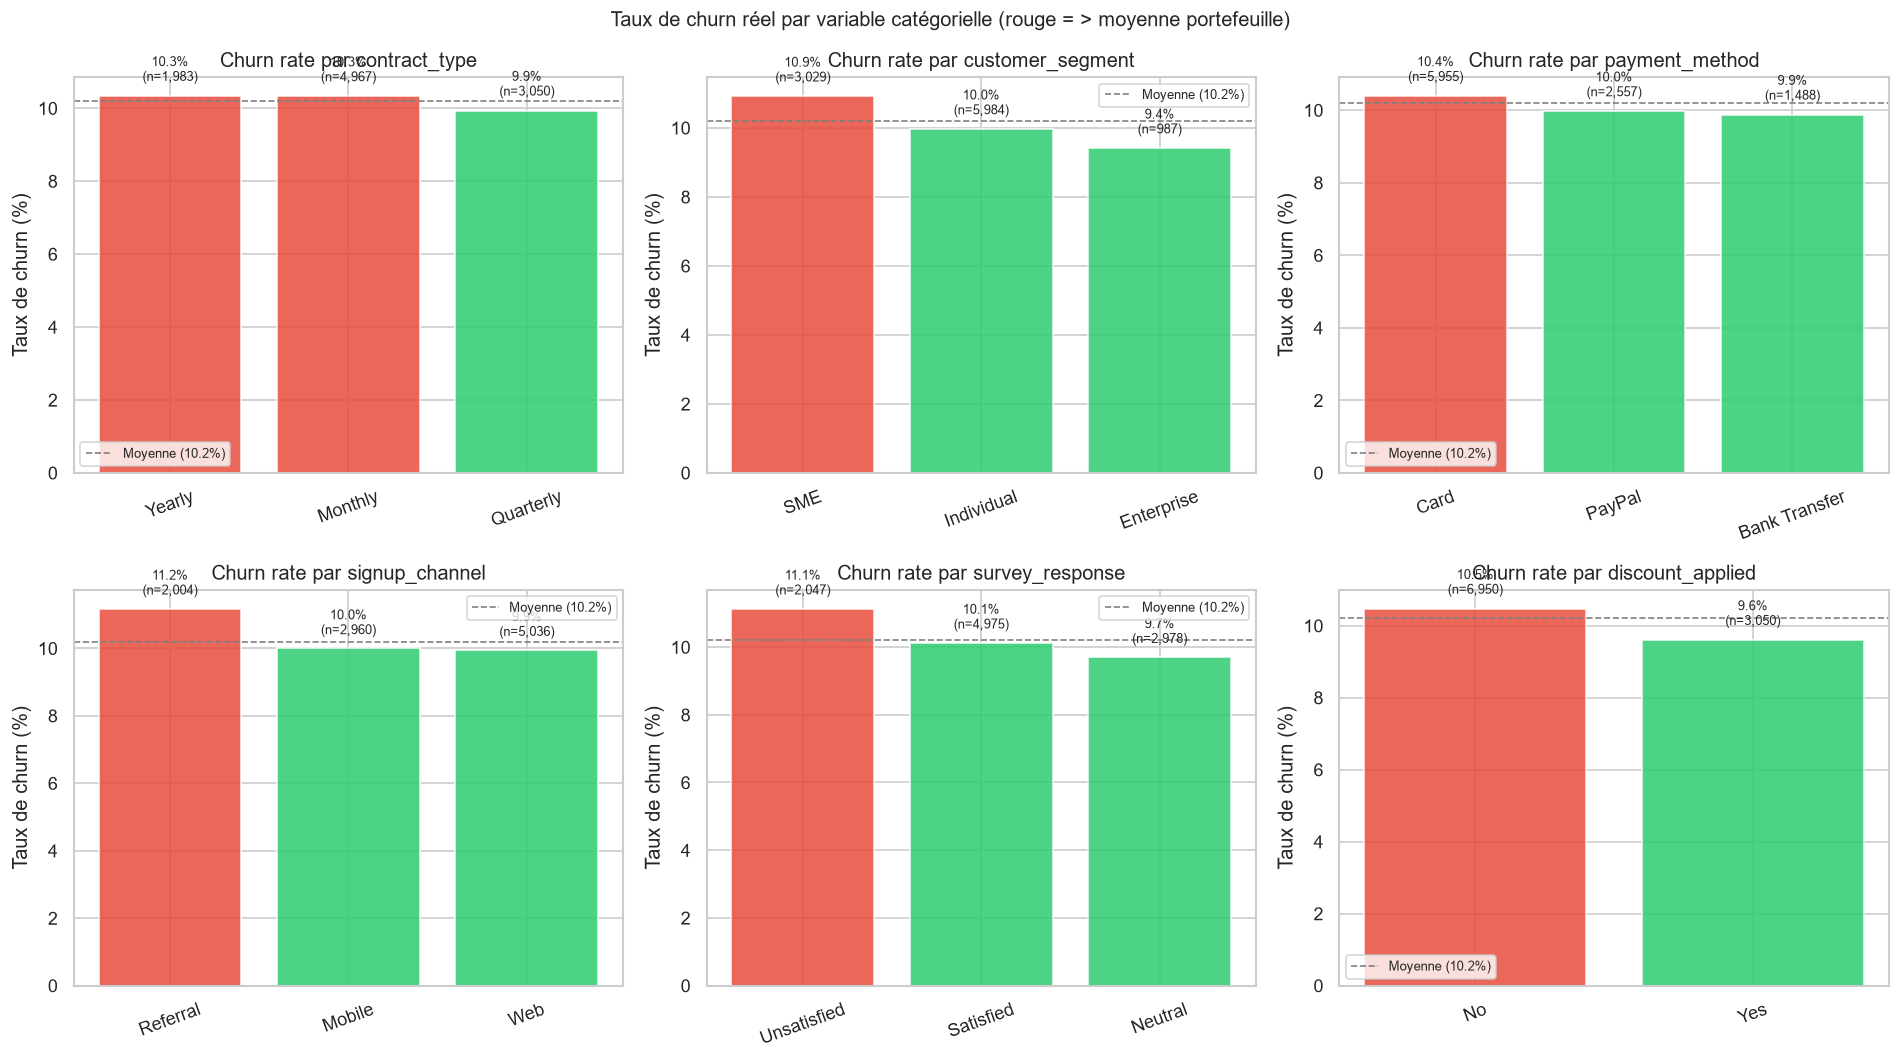

In [9]:
# Taux de churn réel par variable catégorielle
# Cramér's V mesure l'association statistique — ici on calcule le taux de churn réel par modalité
# pour identifier quelles catégories concentrent le risque (rouge = au-dessus de la moyenne)
cat_vars = ['contract_type', 'customer_segment', 'payment_method',
            'signup_channel', 'survey_response', 'discount_applied']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, var in enumerate(cat_vars):
    churn_by_cat = (
        df.groupby(var)['churn']
        .agg(['mean', 'count']).reset_index()
        .sort_values('mean', ascending=False)
    )
    # Rouge si le taux de churn dépasse la moyenne du portefeuille (10.2%), vert sinon
    colors = ['#e74c3c' if r > 0.102 else '#2ecc71' for r in churn_by_cat['mean']]
    bars = axes[i].bar(churn_by_cat[var], churn_by_cat['mean'] * 100, color=colors, alpha=0.85)
    axes[i].axhline(10.2, color='gray', linestyle='--', linewidth=1, label='Moyenne (10.2%)')
    axes[i].set_title(f'Churn rate par {var}')
    axes[i].set_ylabel('Taux de churn (%)')
    axes[i].tick_params(axis='x', rotation=20)
    # Annoter chaque barre avec le taux et le nombre de clients
    for bar, (_, row) in zip(bars, churn_by_cat.iterrows()):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{row["mean"]*100:.1f}%\n(n={row["count"]:,})',
            ha='center', va='bottom', fontsize=8,
        )
    axes[i].legend(fontsize=8)

plt.suptitle('Taux de churn réel par variable catégorielle (rouge = > moyenne portefeuille)', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/figures/01_churn_by_category.png', bbox_inches='tight')
plt.show()

## 8. monthly_fee — variable ordinale déguisée en numérique

Le tableau d'outliers IQR (section 13) signale 513 outliers pour `monthly_fee`. Ce n'est pas de la vraie anomalie : `monthly_fee` n'a que **6 valeurs distinctes** (tiers tarifaires). La méthode IQR identifie à tort le tier 100€ comme outlier. On l'analyse ici correctement, par tier.

Valeurs uniques de monthly_fee : [np.int64(10), np.int64(20), np.int64(30), np.int64(50), np.int64(70), np.int64(100)]
→ C'est une variable ordinale à 6 niveaux, pas une distribution continue.



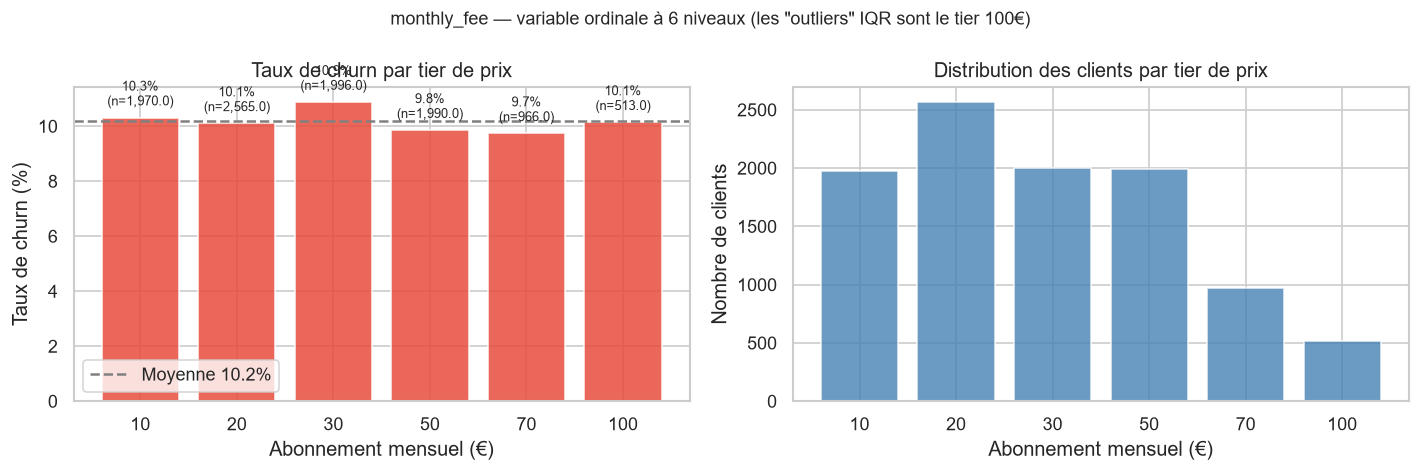

 tier_€  churn_rate  n_clients
     10    0.103046       1970
     20    0.100975       2565
     30    0.108717       1996
     50    0.098492       1990
     70    0.097308        966
    100    0.101365        513

→ Le pipeline traitera monthly_fee comme numérique (StandardScaler), ce qui est valide.
  Un encoding ordinal serait une alternative équivalente pour cette variable.


In [10]:
# monthly_fee n'est PAS une variable continue — seulement 6 valeurs possibles
# Les 513 "outliers" IQR détectés ci-dessus sont simplement les clients au tier 100€
print(f'Valeurs uniques de monthly_fee : {sorted(df["monthly_fee"].unique())}')
print(f'→ C\'est une variable ordinale à 6 niveaux, pas une distribution continue.')
print()

# Taux de churn et effectif par tier de prix
fee_churn = df.groupby('monthly_fee')['churn'].agg(['mean', 'count']).reset_index()
fee_churn.columns = ['tier_€', 'churn_rate', 'n_clients']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graphique gauche : taux de churn par tier
bars = axes[0].bar(fee_churn['tier_€'].astype(str), fee_churn['churn_rate'] * 100,
                   color='#e74c3c', alpha=0.85)
axes[0].axhline(10.2, color='gray', linestyle='--', label='Moyenne 10.2%')
axes[0].set_xlabel('Abonnement mensuel (€)')
axes[0].set_ylabel('Taux de churn (%)')
axes[0].set_title('Taux de churn par tier de prix')
# Annoter chaque barre : taux + effectif
for bar, (_, row) in zip(bars, fee_churn.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{row["churn_rate"]*100:.1f}%\n(n={row["n_clients"]:,})',
                 ha='center', va='bottom', fontsize=8)
axes[0].legend()

# Graphique droite : répartition des clients par tier (pour juger de la représentativité)
axes[1].bar(fee_churn['tier_€'].astype(str), fee_churn['n_clients'], color='steelblue', alpha=0.8)
axes[1].set_xlabel('Abonnement mensuel (€)')
axes[1].set_ylabel('Nombre de clients')
axes[1].set_title('Distribution des clients par tier de prix')

plt.suptitle('monthly_fee — variable ordinale à 6 niveaux (les "outliers" IQR sont le tier 100€)', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/figures/01_monthly_fee_tiers.png', bbox_inches='tight')
plt.show()

print(fee_churn.to_string(index=False))
print('\n→ Le pipeline traitera monthly_fee comme numérique (StandardScaler), ce qui est valide.')
print('  Un encoding ordinal serait une alternative équivalente pour cette variable.')

## 9. Vérification de multicolinéarité — total_revenue

`total_revenue` pourrait être très proche de `monthly_fee × tenure_months`. Si c'est le cas, garder les deux dans le modèle reviendrait à donner deux fois le même signal — et pourrait gonfler artificiellement leur importance SHAP combinée.

Corrélation total_revenue vs (monthly_fee × tenure_months) : 1.0000


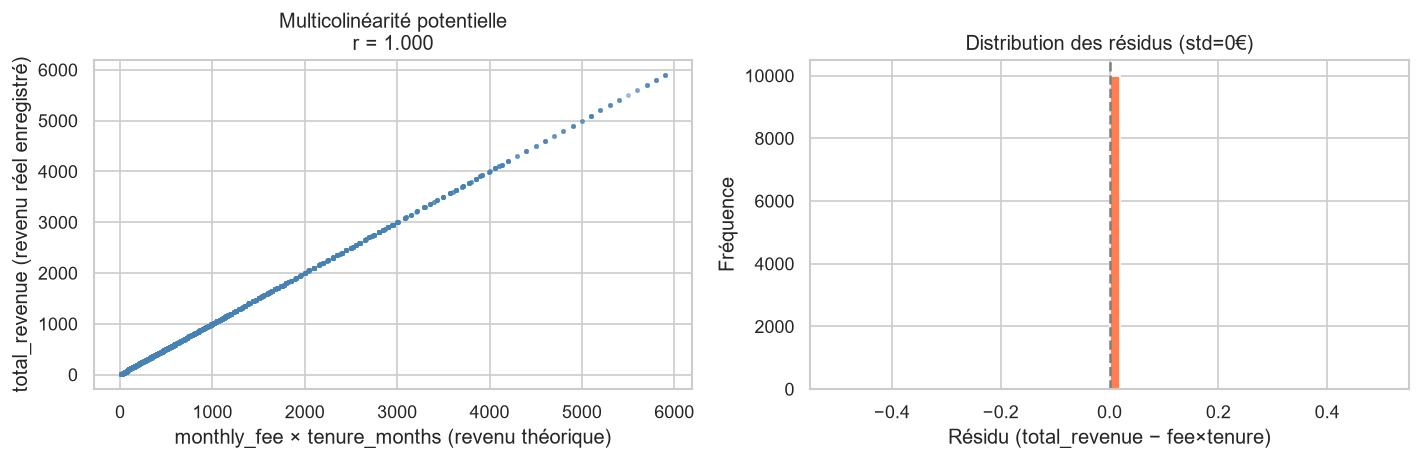


⚠  Forte colinéarité (r=1.000) : les deux variables transportent une information similaire.
   Le pipeline les conserve toutes les deux — la régularisation du MLP et les valeurs SHAP
   permettront d'évaluer laquelle est réellement prédictive.


In [11]:
# Vérification de multicolinéarité : total_revenue ≈ monthly_fee × tenure_months ?
# Si la corrélation est trop forte (> 0.9), garder les deux features apporterait peu
# d'information supplémentaire et pourrait déstabiliser certains modèles linéaires
df_check = df.copy()
df_check['expected_revenue'] = df_check['monthly_fee'] * df_check['tenure_months']

corr_val = df_check['total_revenue'].corr(df_check['expected_revenue'])
print(f'Corrélation total_revenue vs (monthly_fee × tenure_months) : {corr_val:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Nuage de points : revenu réel vs revenu théorique (fee × tenure)
axes[0].scatter(df_check['expected_revenue'], df_check['total_revenue'],
                alpha=0.15, s=4, color='steelblue')
axes[0].set_xlabel('monthly_fee × tenure_months (revenu théorique)')
axes[0].set_ylabel('total_revenue (revenu réel enregistré)')
axes[0].set_title(f'Multicolinéarité potentielle\nr = {corr_val:.3f}')

# Distribution des résidus (écart entre revenu réel et théorique)
# Un résidu élevé peut indiquer des remises, rétroactivité ou historique de tarifs
residus = df_check['total_revenue'] - df_check['expected_revenue']
axes[1].hist(residus, bins=50, color='coral', edgecolor='white')
axes[1].axvline(0, color='gray', linestyle='--')
axes[1].set_xlabel('Résidu (total_revenue − fee×tenure)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title(f'Distribution des résidus (std={residus.std():.0f}€)')

plt.tight_layout()
plt.savefig('../reports/figures/01_multicollinearity_revenue.png', bbox_inches='tight')
plt.show()

if corr_val > 0.9:
    print(f'\n⚠  Forte colinéarité (r={corr_val:.3f}) : les deux variables transportent une information similaire.')
    print('   Le pipeline les conserve toutes les deux — la régularisation du MLP et les valeurs SHAP')
    print('   permettront d\'évaluer laquelle est réellement prédictive.')
else:
    print(f'\n✓  Corrélation modérée (r={corr_val:.3f}) : total_revenue apporte une information complémentaire')
    print('  (remises commerciales, historique de tarification variable) — les deux features sont utiles.')

## 10. CSAT Score — analyse bivariée approfondie

`csat_score` n'apparaît pas dans les KDE plots (trop peu de valeurs distinctes pour une densité lisible). On l'analyse ici avec un barplot de taux de churn par niveau — c'est la variable la plus prédictive du dataset.

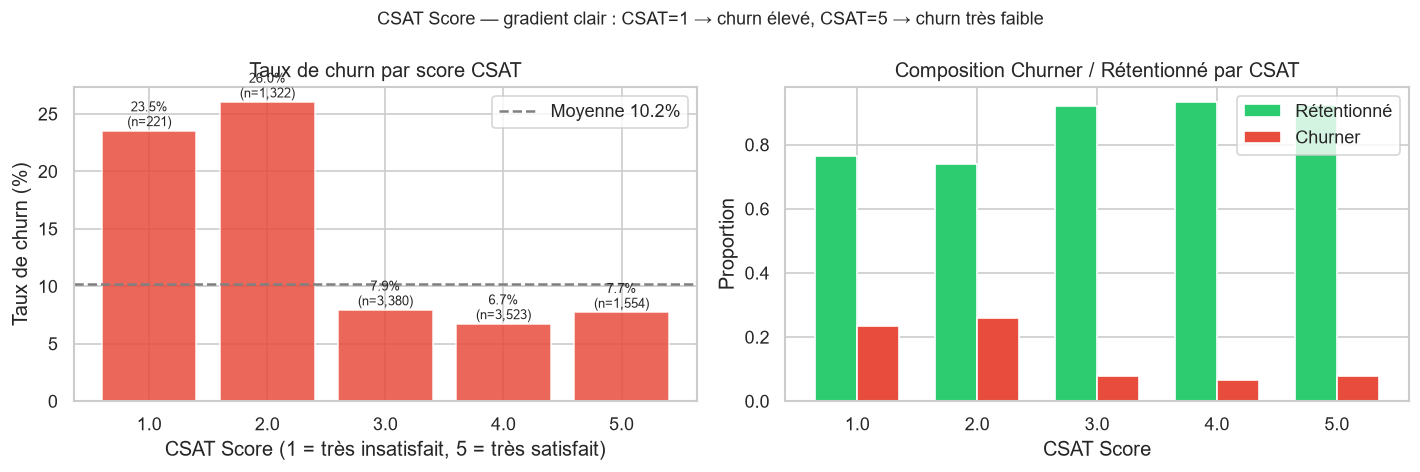

Taux de churn par CSAT :
  CSAT=1 : 23.5%  (n=221)
  CSAT=2 : 26.0%  (n=1,322)
  CSAT=3 : 7.9%  (n=3,380)
  CSAT=4 : 6.7%  (n=3,523)
  CSAT=5 : 7.7%  (n=1,554)

→ La relation CSAT → churn est quasi-monotone décroissante. C'est la variable avec le
  signal prédictif le plus direct — confirmé plus tard par la Permutation Importance (Δ F1 = 0.076).


In [12]:
# csat_score — variable continue mais à 5 niveaux discrets : analyse du signal churn
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Taux de churn par score CSAT (barplot)
csat_churn = df.groupby('csat_score')['churn'].agg(['mean', 'count']).reset_index()
axes[0].bar(csat_churn['csat_score'].astype(str), csat_churn['mean'] * 100,
            color='#e74c3c', alpha=0.85)
axes[0].axhline(10.2, color='gray', linestyle='--', label='Moyenne 10.2%')
axes[0].set_xlabel('CSAT Score (1 = très insatisfait, 5 = très satisfait)')
axes[0].set_ylabel('Taux de churn (%)')
axes[0].set_title('Taux de churn par score CSAT')
for _, row in csat_churn.iterrows():
    axes[0].text(
        csat_churn[csat_churn['csat_score'] == row['csat_score']].index[0],
        row['mean'] * 100 + 0.4,
        f"{row['mean']*100:.1f}%\n(n={int(row['count']):,})",
        ha='center', fontsize=8,
    )
axes[0].legend()

# Distribution de CSAT — churners vs rétentionnés (normalisée)
csat_dist = df.groupby(['csat_score', 'churn']).size().unstack(fill_value=0)
csat_dist_pct = csat_dist.div(csat_dist.sum(axis=1), axis=0)
csat_dist_pct.rename(columns={0: 'Rétentionné', 1: 'Churner'}).plot(
    kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], width=0.7,
)
axes[1].set_xlabel('CSAT Score')
axes[1].set_ylabel('Proportion')
axes[1].set_title('Composition Churner / Rétentionné par CSAT')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(loc='upper right')

plt.suptitle('CSAT Score — gradient clair : CSAT=1 → churn élevé, CSAT=5 → churn très faible', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/figures/01_csat_vs_churn.png', bbox_inches='tight')
plt.show()

print('Taux de churn par CSAT :')
for _, row in csat_churn.iterrows():
    print(f'  CSAT={int(row["csat_score"])} : {row["mean"]*100:.1f}%  (n={int(row["count"]):,})')
print('\n→ La relation CSAT → churn est quasi-monotone décroissante. C\'est la variable avec le')
print('  signal prédictif le plus direct — confirmé plus tard par la Permutation Importance (Δ F1 = 0.076).')

## 11. Churn par tranche d'ancienneté

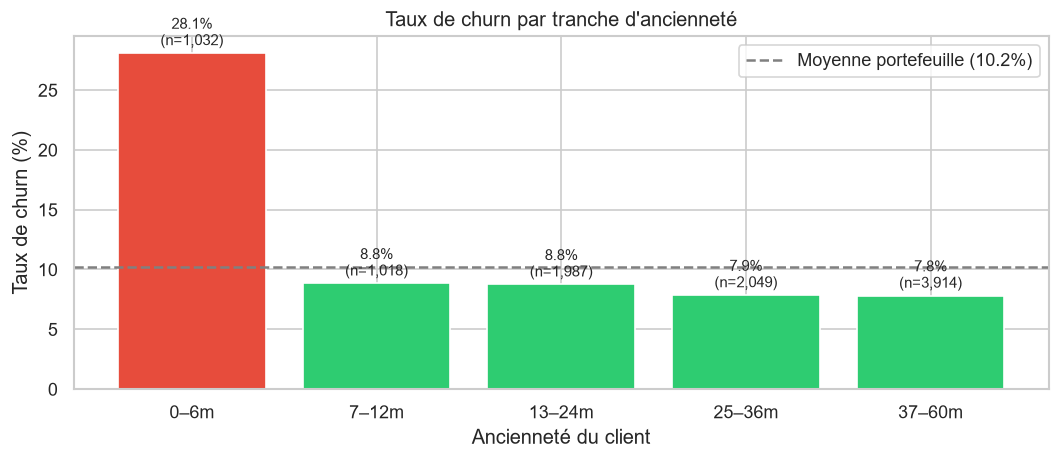

→ Les clients < 12 mois churnen massivement — signal d'échec d'onboarding.
   Les clients > 36 mois sont nettement plus fidèles — tenure est un proxy de satisfaction cumulée.


In [13]:
# Churn rate par tranche d'ancienneté — les nouveaux clients sont les plus à risque
df_tenure = df.copy()
df_tenure['tenure_bucket'] = pd.cut(
    df_tenure['tenure_months'],
    bins=[0, 6, 12, 24, 36, 60],
    labels=['0–6m', '7–12m', '13–24m', '25–36m', '37–60m']
)

tenure_churn = (
    df_tenure.groupby('tenure_bucket', observed=True)['churn']
    .agg(['mean', 'count']).reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(
    tenure_churn['tenure_bucket'].astype(str),
    tenure_churn['mean'] * 100,
    color=['#e74c3c' if r > 0.102 else '#2ecc71' for r in tenure_churn['mean']],
)
ax.axhline(10.2, color='gray', linestyle='--', label='Moyenne portefeuille (10.2%)')
ax.set_xlabel('Ancienneté du client')
ax.set_ylabel('Taux de churn (%)')
ax.set_title('Taux de churn par tranche d\'ancienneté')
for bar, (_, row) in zip(bars, tenure_churn.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
        f'{row["mean"]*100:.1f}%\n(n={row["count"]:,})',
        ha='center', va='bottom', fontsize=9,
    )
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/01_churn_by_tenure.png', bbox_inches='tight')
plt.show()

print('→ Les clients < 12 mois churnen massivement — signal d\'échec d\'onboarding.')
print('   Les clients > 36 mois sont nettement plus fidèles — tenure est un proxy de satisfaction cumulée.')

## 12. Valeurs manquantes — complaint_type vs churn

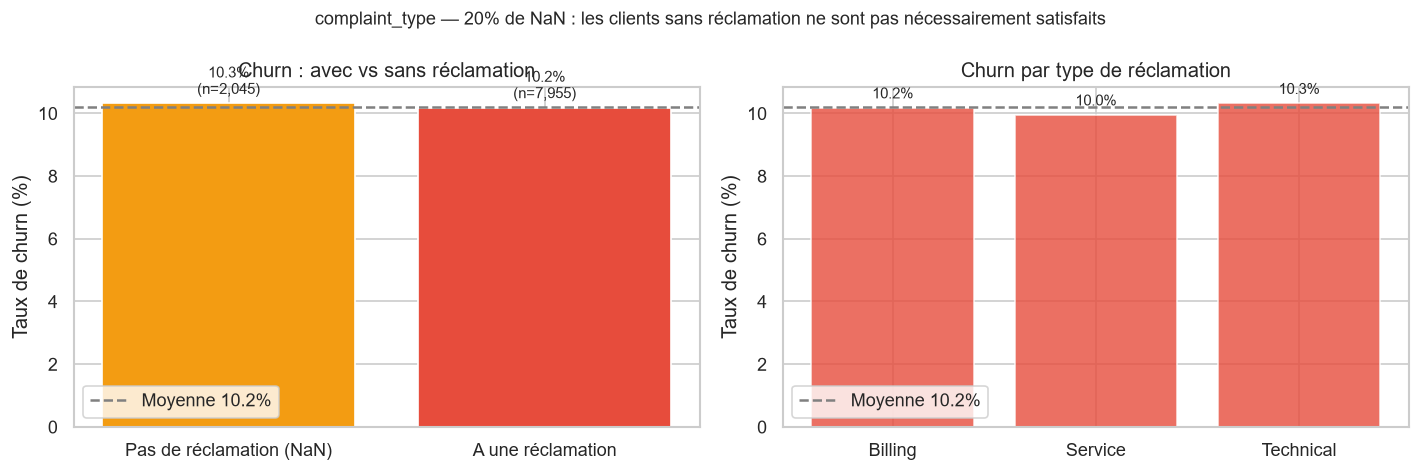

Churn sans réclamation : 10.3%
Churn avec réclamation : 10.2%
→ L'absence de réclamation peut signifier désengagement silencieux (imputation "Unknown" justifiée)


In [14]:
# Taux de churn réel par type de réclamation et présence/absence de réclamation
df_complaint = df.copy()
df_complaint['has_complaint'] = df_complaint['complaint_type'].notna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Churn rate avec/sans réclamation
ca = df_complaint.groupby('has_complaint')['churn'].agg(['mean', 'count']).reset_index()
ca['label'] = ca['has_complaint'].map({True: 'A une réclamation', False: 'Pas de réclamation (NaN)'})
axes[0].bar(ca['label'], ca['mean'] * 100, color=['#f39c12', '#e74c3c'])
axes[0].axhline(10.2, color='gray', linestyle='--', label='Moyenne 10.2%')
axes[0].set_ylabel('Taux de churn (%)')
axes[0].set_title('Churn : avec vs sans réclamation')
for i, row in ca.iterrows():
    axes[0].text(i, row['mean']*100 + 0.3, f'{row["mean"]*100:.1f}%\n(n={row["count"]:,})', ha='center', fontsize=9)
axes[0].legend()

# Churn rate par type de réclamation (hors NaN)
tc = df.dropna(subset=['complaint_type']).groupby('complaint_type')['churn'].agg(['mean', 'count']).reset_index()
axes[1].bar(tc['complaint_type'], tc['mean'] * 100, color='#e74c3c', alpha=0.8)
axes[1].axhline(10.2, color='gray', linestyle='--', label='Moyenne 10.2%')
axes[1].set_ylabel('Taux de churn (%)')
axes[1].set_title('Churn par type de réclamation')
for i, row in tc.iterrows():
    axes[1].text(i, row['mean']*100 + 0.3, f'{row["mean"]*100:.1f}%', ha='center', fontsize=9)
axes[1].legend()

plt.suptitle("complaint_type — 20% de NaN : les clients sans réclamation ne sont pas nécessairement satisfaits", fontsize=11)
plt.tight_layout()
plt.savefig('../reports/figures/01_complaint_type_analysis.png', bbox_inches='tight')
plt.show()

print(f'Churn sans réclamation : {ca.loc[~ca["has_complaint"], "mean"].values[0]*100:.1f}%')
print(f'Churn avec réclamation : {ca.loc[ca["has_complaint"], "mean"].values[0]*100:.1f}%')
print('→ L\'absence de réclamation peut signifier désengagement silencieux (imputation "Unknown" justifiée)')

## 13. Détection d'outliers (IQR)

In [15]:
outlier_report = {}
for col in key_vars:
    if col not in df.columns:
        continue
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    outlier_report[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR, 'n_outliers': n_out, 'pct': n_out/len(df)*100}

pd.DataFrame(outlier_report).T.round(2)

,Q1,Q3,IQR,n_outliers,pct
tenure_months,16.0,45.0,29.0,0.0,0.00
monthly_fee,20.0,50.0,30.0,513.0,5.13
payment_failures,0.0,1.0,1.0,147.0,1.47
nps_score,-7.0,46.0,53.0,36.0,0.36
support_tickets,0.0,2.0,2.0,18.0,0.18
monthly_logins,13.0,26.0,13.0,49.0,0.49


## 14. Variables dérivées prometteuses

In [16]:
df_eng = df.copy()
df_eng['tickets_per_tenure']  = df_eng['support_tickets'] / (df_eng['tenure_months'] + 1)
df_eng['fee_per_tenure']  = df_eng['monthly_fee'] / (df_eng['tenure_months'] + 1)

for feat in ['tickets_per_tenure', 'fee_per_tenure']:
    corr_with_churn = df_eng[feat].corr(df_eng['churn'])
    print(f'{feat}: corrélation avec churn = {corr_with_churn:.4f}')
    
print('\n→ Ces features seront ajoutées au pipeline de modélisation si leur corrélation est positive.')

tickets_per_tenure: corrélation avec churn = 0.1217
fee_per_tenure: corrélation avec churn = 0.1424

→ Ces features seront ajoutées au pipeline de modélisation si leur corrélation est positive.


## 15. Synthèse EDA

| Observation | Implication pour la modélisation |
|---|---|
| 10.2% de churners — classes très déséquilibrées | Priorité à F1 et PR-AUC ; `class_weight='balanced'` indispensable |
| `csat_score` — gradient quasi-monotone (CSAT=1 → churn élevé, CSAT=5 → faible) | Variable attendue en tête de la Permutation Importance et des SHAP values |
| `nps_score` et `survey_response` — corrélation négative forte avec le churn | Signal d'insatisfaction cumulée à capter dès le preprocessing |
| `contract_type` — association Cramér's V significative | Encoder soigneusement (OHE), ne pas agréger avec d'autres catégories |
| Nouveaux clients (tenure < 12 mois) — taux de churn nettement plus élevé | `fee_per_tenure` : corrélation +0.14 avec le churn, à intégrer dans le pipeline |
| `monthly_fee` — 6 valeurs discrètes, pas une distribution continue | Les 513 "outliers" IQR sont le tier 100€ ; traiter comme numérique (StandardScaler) |
| `total_revenue` — colinéarité avec `monthly_fee × tenure_months` | Conserver les deux ; la régularisation et SHAP permettront de trancher |
| `complaint_type` : 20% de valeurs manquantes | Imputation "Unknown" justifiée — absence de plainte déclarée = désengagement silencieux |
| `payment_failures` — corrélation positive avec le churn | Signal de stress financier à croiser avec `price_increase_last_3m` |

**Ce que révèle l'EDA :** le churn n'est pas un signal simple. L'insatisfaction visible (CSAT bas, NPS négatif, tickets support) coexiste avec des profils récents qui partent sans laisser de trace apparente (clients 0–6 mois, sans réclamation). Le modèle devra capturer ces deux logiques différentes.

**Prochaine étape :** `02_preprocessing.ipynb` — construire le pipeline en évitant toute fuite de données.